In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("/kaggle/input/datasets/kohinrahman/kohinrahman/Air_BNB.xlsx")

In [3]:
data.drop('id',axis=1,inplace=True)

In [4]:
num = []
cat = []
bl = []
for i in data.columns:
    if data[i].dtype=='object':
        cat.append(i)
    elif data[i].dtype=='bool':
        bl.append(i)
    else:
        num.append(i)

In [5]:
num

['accommodates',
 'bathrooms',
 'review_scores_rating',
 'bedrooms',
 'beds',
 'log_price']

In [6]:
dependent_var = 'log_price'

In [7]:
num.remove(dependent_var)

In [8]:
num

['accommodates', 'bathrooms', 'review_scores_rating', 'bedrooms', 'beds']

In [9]:
t = data[num].corr()

In [10]:
t

,accommodates,bathrooms,review_scores_rating,bedrooms,beds
accommodates,1.000000,0.505632,-0.017128,0.709258,0.810801
bathrooms,0.505632,1.000000,0.010537,0.589935,0.525591
review_scores_rating,-0.017128,0.010537,1.000000,0.011143,-0.027330
bedrooms,0.709258,0.589935,0.011143,1.000000,0.709416
beds,0.810801,0.525591,-0.027330,0.709416,1.000000


<Axes: >

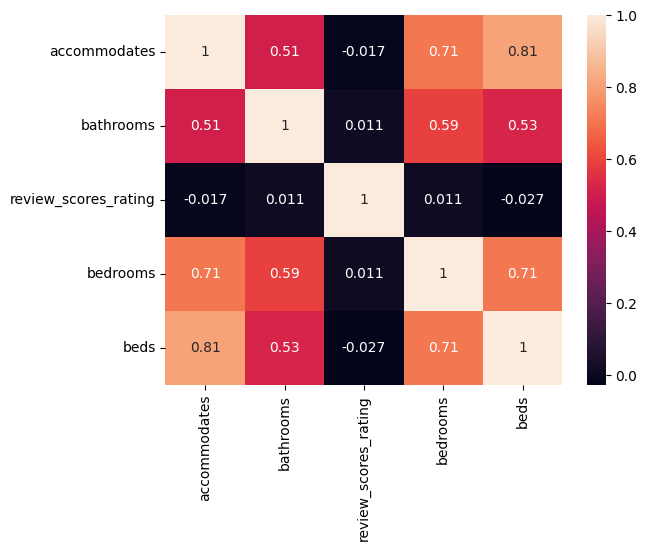

In [11]:
sns.heatmap(data[num].corr(),annot = True,fmt='.2g')

In [15]:
threshold = 0.70
selected_feature = t.copy()
for i in range(t.shape[0]):
    for j in range(t.shape[1]):
        if i!=j and (abs(t.values[i,j]).round(2) >= threshold):
            feature = t.columns[j]
            selected_feature.drop(feature,axis=0,inplace=True)
            selected_feature.drop(feature,axis=1,inplace=True)
print(selected_feature)

KeyError: "['beds'] not found in axis"